# INDICATOR CLUSTERING (Cross-indicator relationship mapping)

### Core Question Answered

#### Which indicators behave similarly across countries and time? Are there underlying “hidden dimensions” where indicators move together?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [3]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [4]:
OUTPUT_DIR = Path("../worldbank_tableau_project/outputs/indicator_CLu")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('../worldbank_tableau_project/outputs/indicator_CLu')

In [5]:
df = pd.read_csv("data/feature_engineered_data.csv")

In [6]:
df["indicator_name"].nunique()


42

In [7]:
df.columns

Index(['country_name', 'year', 'value', 'indicator_id', 'indicator_name',
       'unit_type', 'source', 'source_reliable', 'region', 'category',
       'val_num', 'yoy_change', 'yoy_pct_change', 'yoy_pct_exists',
       'rolling_mean_3y', 'rolling_std_3y', 'rolling_mean_5y',
       'rolling_std_5y', 'cagr', 'spike', 'dip', 'outlier', 'trend_slope',
       'coef_variation', 'momentum', 'regional_deviation',
       'regional_deviation_std', 'event_global', 'event_country'],
      dtype='object')

In [8]:
indicator_min_years = (
    df.groupby("indicator_name")["year"].nunique()
)
valid_indicators = indicator_min_years[indicator_min_years >= 10].index
df = df[df["indicator_name"].isin(valid_indicators)]


In [9]:
indicator_df = (
    df.groupby("indicator_name").agg(
        spike_count=("spike", "sum"),
        dip_count=("dip", "sum"),
        avg_volatility=("rolling_std_5y", "mean"),
        slope_mean=("trend_slope", "mean"),
        momentum_mean=("momentum", "mean"),
        coef_variation=("coef_variation", "mean"),
        cagr_mean=("cagr", "mean"),
        regional_dev_std=("regional_deviation_std", "mean"),
        # event exposure (optional but included)
        global_event_count=("event_global", lambda x: x.notna().sum()),
        country_event_count=("event_country", lambda x: x.notna().sum()),
        # category (interpretation only)
        category=("category", lambda x: x.mode()[0])
    )
).reset_index()



In [10]:
indicator_df.head()

,indicator_name,spike_count,dip_count,avg_volatility,slope_mean,momentum_mean,coef_variation,cagr_mean,regional_dev_std,global_event_count,country_event_count,category
0,A woman can apply for a passport in the same w...,7,0,NaN,0.020314,-inf,94.620196,NaN,1.490577e-17,360,61,Other
1,"A woman can be ""head of household"" in the same...",0,4,NaN,0.014300,-inf,73.882191,NaN,1.439178e-17,360,61,Other
2,A woman can choose where to live in the same w...,7,0,NaN,0.003164,-inf,62.335208,NaN,3.083953e-18,360,61,Other
3,A woman can get a job in the same way as a man...,4,0,NaN,0.001932,-inf,25.379566,NaN,8.223874e-18,360,61,Other
4,A woman can obtain a judgment of divorce in th...,0,0,NaN,0.000000,0.0,0.000000,NaN,0.000000e+00,360,61,Other


In [11]:
indicator_df["obs_count"] = df.groupby("indicator_name")["value"].count().values


In [12]:
indicator_df.shape 

(42, 13)

In [13]:
indicator_df.columns

Index(['indicator_name', 'spike_count', 'dip_count', 'avg_volatility',
       'slope_mean', 'momentum_mean', 'coef_variation', 'cagr_mean',
       'regional_dev_std', 'global_event_count', 'country_event_count',
       'category', 'obs_count'],
      dtype='object')

In [14]:
num_cols = ["spike_count", "dip_count", "avg_volatility", 
            "slope_mean", "momentum_mean", "coef_variation","cagr_mean","regional_dev_std","global_event_count", "country_event_count",'obs_count']

In [15]:
indicator_df[num_cols] = indicator_df[num_cols].replace([np.inf, -np.inf], np.nan)
indicator_df[num_cols] = indicator_df[num_cols].fillna(indicator_df[num_cols].median())


In [16]:
indicator_df[num_cols].isna().sum()

spike_count            0
dip_count              0
avg_volatility         0
slope_mean             0
momentum_mean          0
coef_variation         0
cagr_mean              0
regional_dev_std       0
global_event_count     0
country_event_count    0
obs_count              0
dtype: int64

In [17]:
indicator_df[num_cols].std()


spike_count            6.098923e+00
dip_count              2.989723e+00
avg_volatility         1.091200e+05
slope_mean             6.969232e+04
momentum_mean          1.649524e-03
coef_variation         4.638071e+01
cagr_mean              1.625964e+00
regional_dev_std       1.353722e-16
global_event_count     0.000000e+00
country_event_count    0.000000e+00
obs_count              0.000000e+00
dtype: float64

## Drop all 0 features

In [18]:
num_cols = [
    "spike_count",
    "dip_count",
    "avg_volatility",
    "slope_mean",
    "momentum_mean",
    "coef_variation",
    "cagr_mean"
    
]


In [19]:
imp = SimpleImputer(strategy="median")
X_imputed = imp.fit_transform(indicator_df[num_cols])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [20]:
np.isnan(X_scaled).sum()


0

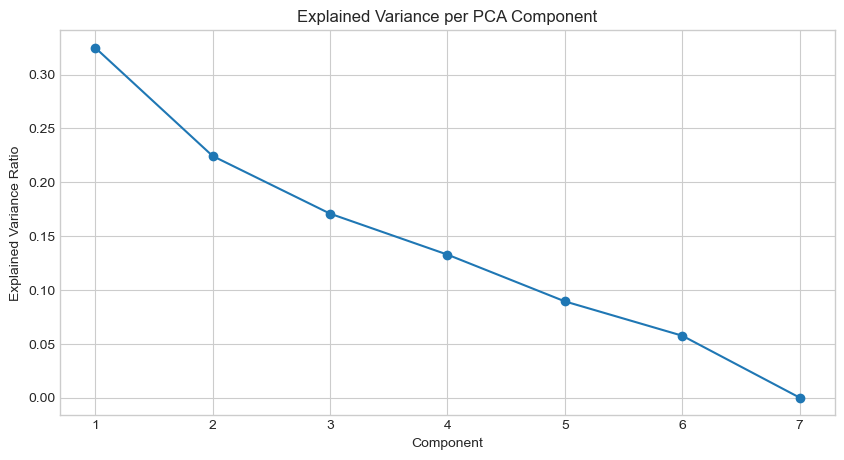

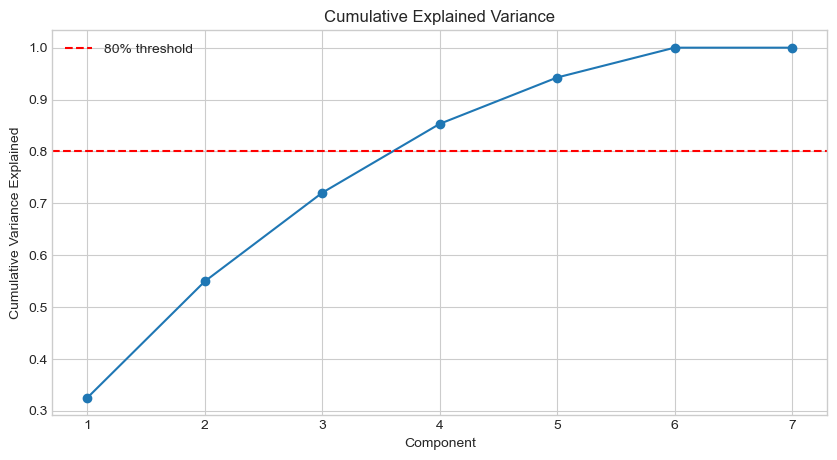

In [21]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Fit PCA with all possible components
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_

plt.figure(figsize=(10,5))
plt.plot(np.arange(1, len(explained)+1), explained, marker='o')
plt.title("Explained Variance per PCA Component")
plt.xlabel("Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(np.arange(1, len(explained)+1), np.cumsum(explained), marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Component")
plt.ylabel("Cumulative Variance Explained")
plt.axhline(0.80, color='red', linestyle='--', label='80% threshold')
plt.legend()
plt.grid(True)
plt.show()


In [22]:
for i, v in enumerate(np.cumsum(explained)):
    print(f"PC1..PC{i+1}: {v:.3f}")


PC1..PC1: 0.325
PC1..PC2: 0.549
PC1..PC3: 0.720
PC1..PC4: 0.853
PC1..PC5: 0.942
PC1..PC6: 1.000
PC1..PC7: 1.000


In [23]:
pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X_scaled)

indicator_df["PC1"] = X_pca[:, 0]
indicator_df["PC2"] = X_pca[:, 1]
indicator_df["PC3"] = X_pca[:, 2]
indicator_df["PC4"] = X_pca[:, 3]

pca.explained_variance_ratio_, pca.explained_variance_ratio_.sum()


(array([0.32496464, 0.22441476, 0.17087226, 0.13282205]), 0.853073711059636)

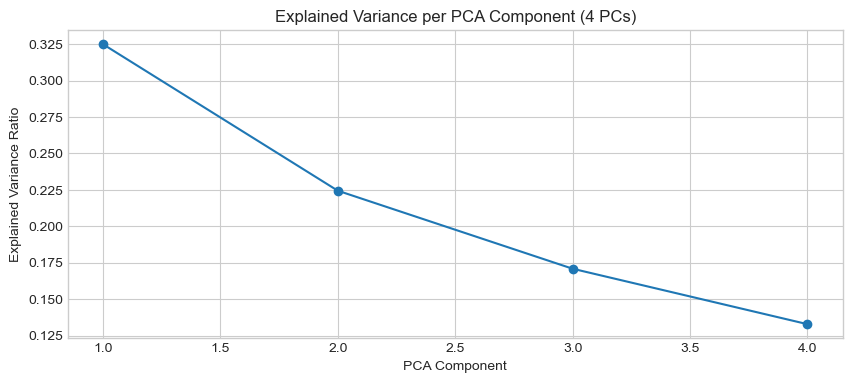

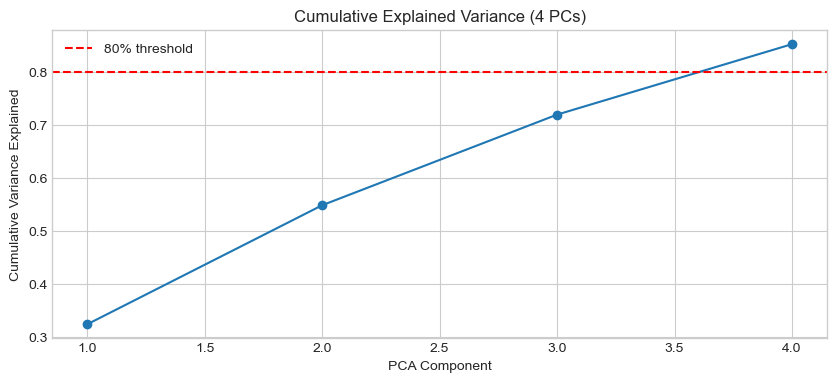

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(range(1,5), pca.explained_variance_ratio_, marker="o")
plt.title("Explained Variance per PCA Component (4 PCs)")
plt.xlabel("PCA Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(range(1,5), pca.explained_variance_ratio_.cumsum(), marker="o")
plt.axhline(0.80, color="red", linestyle="--", label="80% threshold")
plt.title("Cumulative Explained Variance (4 PCs)")
plt.xlabel("PCA Component")
plt.ylabel("Cumulative Variance Explained")
plt.grid(True)
plt.legend()
plt.show()


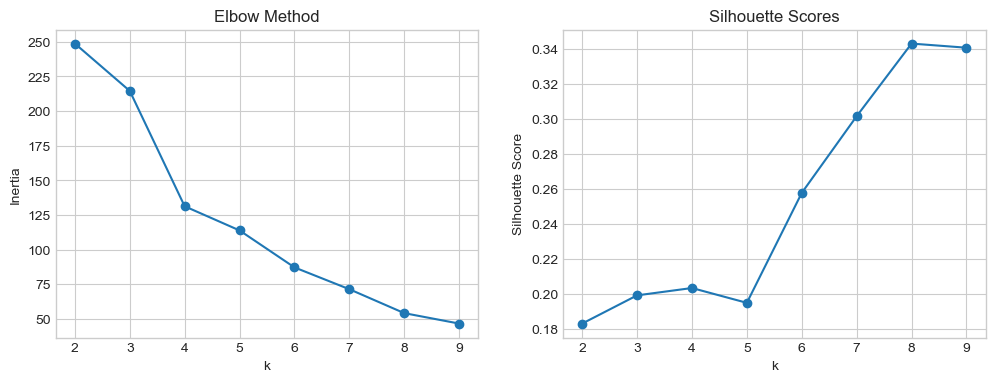

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []

K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot results
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(K, inertias, '-o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(K, silhouettes, '-o')
plt.title("Silhouette Scores")
plt.xlabel("k")
plt.ylabel("Silhouette Score")

plt.savefig(OUTPUT_DIR / "kmeans_elbow_silhouette.png", dpi=300)

plt.show()


In [26]:
k_opt = 8

kmeans = KMeans(n_clusters=k_opt, random_state=42)
indicator_df["indicator_cluster"] = kmeans.fit_predict(X_scaled)


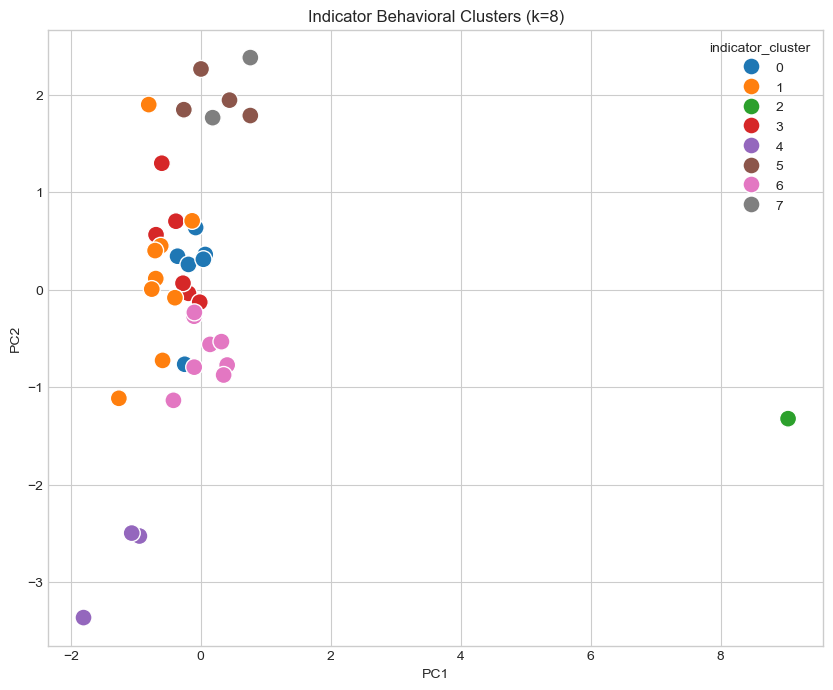

In [27]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=indicator_df,
    x="PC1", y="PC2",
    hue="indicator_cluster",
    palette="tab10",
    s=150
)

plt.title("Indicator Behavioral Clusters (k=8)")
plt.savefig(OUTPUT_DIR / "indicator_clusters_pca.png", dpi=300)
plt.show()


In [28]:
cluster_names = {
    0: "Gradual Structural Demographic",
    1: "Highly Volatile, Reform-Sensitive",
    2: "Outlier: Population Dynamics",
    3: "Stable Legal Rights",
    4: "Declining Health & Fertility",
    5: "Growing Participation & Economic",
    6: "Fully Stabilized Rights",
    7: "Labor Market Stress & Unemployment"
}

indicator_df["cluster_name"] = indicator_df["indicator_cluster"].map(cluster_names)


In [46]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2","PC3","PC4"],
    index=num_cols
)
loadings


,PC1,PC2,PC3,PC4
spike_count,-0.295615,0.040443,0.649332,0.135656
dip_count,-0.104059,0.440518,-0.006784,0.813249
avg_volatility,0.620315,-0.131023,0.254282,0.103776
slope_mean,0.620360,-0.131429,0.254159,0.102943
momentum_mean,-0.137004,-0.558836,0.243825,0.399856
coef_variation,-0.121958,0.333469,0.622396,-0.372321
cagr_mean,0.313850,0.588531,-0.047309,0.018693


In [30]:
def pretty_list(lst):
    return "\n".join("• " + x for x in lst)

summary_table = (
    indicator_df
    .groupby(["indicator_cluster", "cluster_name"])
    .agg(
        indicator_list=("indicator_name", lambda x: pretty_list(list(x))),
        spike_count=("spike_count", "mean"),
        dip_count=("dip_count", "mean"),
        avg_volatility=("avg_volatility", "mean"),
        slope_mean=("slope_mean", "mean"),
        cagr_mean=("cagr_mean", "mean"),
        momentum_mean=("momentum_mean", "mean"),
        coef_variation=("coef_variation", "mean")
    )
    .reset_index()
)

summary_table


,indicator_cluster,cluster_name,indicator_list,spike_count,dip_count,avg_volatility,slope_mean,cagr_mean,momentum_mean,coef_variation
0,0,Gradual Structural Demographic,"• A woman can be ""head of household"" in the sa...",3.166667,6.833333,0.957902,0.035065,-0.071579,0.000238,18.433308
1,1,"Highly Volatile, Reform-Sensitive","• Inflation, consumer prices (annual %)\n• Pro...",15.666667,3.666667,943.493371,360.010969,0.074632,-0.000008,52.051962
2,2,Outlier: Population Dynamics,"• Population, total",0.000000,0.000000,707395.433593,451740.410676,3.037064,-0.000058,19.448991
3,3,Stable Legal Rights,• A woman can apply for a passport in the same...,7.666667,1.333333,1.728872,0.012927,0.279537,0.000000,128.279850
4,4,Declining Health & Fertility,"• Adolescent fertility rate (births per 1,000 ...",14.000000,0.666667,2.091453,-0.645944,-2.682624,0.003826,24.796514
5,5,Growing Participation & Economic,• GDP per capita (current US$)\n• Proportion o...,7.500000,6.500000,592.586685,140.842228,3.412640,-0.000087,73.871684
6,6,Fully Stabilized Rights,• A woman can choose where to live in the same...,2.909091,0.181818,1.477897,0.003959,0.026816,0.000008,19.237955
7,7,Labor Market Stress & Unemployment,"• Unemployment, female (% of female labor forc...",8.500000,3.000000,1.024937,0.145925,1.470510,-0.005029,24.889266


In [31]:
summary_table_display = summary_table[[
    "indicator_cluster",
    "cluster_name", 
    "indicator_list",
    "spike_count", 
    "dip_count", 
    "avg_volatility",
    "slope_mean",
    "cagr_mean",
    "momentum_mean",
    "coef_variation"
]]
summary_table_display

,indicator_cluster,cluster_name,indicator_list,spike_count,dip_count,avg_volatility,slope_mean,cagr_mean,momentum_mean,coef_variation
0,0,Gradual Structural Demographic,"• A woman can be ""head of household"" in the sa...",3.166667,6.833333,0.957902,0.035065,-0.071579,0.000238,18.433308
1,1,"Highly Volatile, Reform-Sensitive","• Inflation, consumer prices (annual %)\n• Pro...",15.666667,3.666667,943.493371,360.010969,0.074632,-0.000008,52.051962
2,2,Outlier: Population Dynamics,"• Population, total",0.000000,0.000000,707395.433593,451740.410676,3.037064,-0.000058,19.448991
3,3,Stable Legal Rights,• A woman can apply for a passport in the same...,7.666667,1.333333,1.728872,0.012927,0.279537,0.000000,128.279850
4,4,Declining Health & Fertility,"• Adolescent fertility rate (births per 1,000 ...",14.000000,0.666667,2.091453,-0.645944,-2.682624,0.003826,24.796514
5,5,Growing Participation & Economic,• GDP per capita (current US$)\n• Proportion o...,7.500000,6.500000,592.586685,140.842228,3.412640,-0.000087,73.871684
6,6,Fully Stabilized Rights,• A woman can choose where to live in the same...,2.909091,0.181818,1.477897,0.003959,0.026816,0.000008,19.237955
7,7,Labor Market Stress & Unemployment,"• Unemployment, female (% of female labor forc...",8.500000,3.000000,1.024937,0.145925,1.470510,-0.005029,24.889266


In [48]:
summary_table.to_csv(OUTPUT_DIR / "2Indicator_Cluster_summary.csv", index=False)

## Generate Narrative

In [32]:
def generate_indicator_cluster_narrative(cluster_id, summary_table, cluster_names):
    """
    Generates a narrative for an indicator behavioral cluster based on summary statistics.
    """

    row = summary_table[summary_table["indicator_cluster"] == cluster_id].iloc[0]

    name = row["cluster_name"]
    indicators = row["indicator_list"]

    spike = row["spike_count"]
    dip = row["dip_count"]
    vol = row["avg_volatility"]
    slope = row["slope_mean"]
    momentum = row["momentum_mean"]
    cagr = row["cagr_mean"]
    cv = row["coef_variation"]

    # --- Behavioral Interpretation Rules ---
    behavior = []

    # Volatility
    if vol > summary_table["avg_volatility"].mean():
        behavior.append("high volatility and sensitivity to shocks")
    else:
        behavior.append("low volatility and stable year-to-year behavior")

    # Trend slope
    if slope > 0:
        behavior.append("a positive long-term improvement trend")
    elif slope < 0:
        behavior.append("a declining long-term trajectory")
    else:
        behavior.append("a flat long-term trajectory")

    # Momentum (recent vs long term)
    if momentum > 0:
        behavior.append("recent acceleration in progress")
    elif momentum < 0:
        behavior.append("recent slowdown or reversal")
    else:
        behavior.append("stable short-term movement")

    # CAGR
    if cagr > 0:
        behavior.append("compound growth over time")
    else:
        behavior.append("compound decline over time")

    # Shock events (spikes & dips)
    shock_profile = []
    if spike > dip:
        shock_profile.append("more upward spikes than dips, indicating reform-triggered jumps")
    elif dip > spike:
        shock_profile.append("more downward dips than spikes, indicating crisis exposure")
    else:
        shock_profile.append("balanced spikes and dips")

    # CV (coefficient of variation)
    if cv > summary_table["coef_variation"].mean():
        behavior.append("large cross-country variation")
    else:
        behavior.append("consistent behavior across countries")

    # Final narrative assembly
    narrative = f"""
# Indicator Cluster {cluster_id}: {name}

### **Core Identity**
This cluster captures indicators characterized by **{' and '.join(behavior)}**.
Its behavioral profile reveals how this group of indicators contributes to regional gender dynamics.

### **Indicators in This Cluster**
{indicators}

### **Shock Sensitivity**
This cluster exhibits **{', '.join(shock_profile)}**, revealing how quickly indicators in this group react to political, economic, or social disruptions.

### **Long-Term Behavior**
- Average trend slope: **{slope:.3f}**
- CAGR: **{cagr:.3f}**
- Momentum: **{momentum:.5f}**

Together, these metrics show that the cluster displays **{'improving' if slope>0 else 'declining' if slope<0 else 'flat'}** long-term behavior with **{'accelerating' if momentum>0 else 'slowing' if momentum<0 else 'stable'}** short-term dynamics.

### **Volatility Profile**
The mean 5-year rolling standard deviation is **{vol:.3f}**, indicating that the cluster is **{'shock-sensitive' if vol>summary_table['avg_volatility'].mean() else 'structurally stable'}**.

### **Interpretation**
This cluster plays a key role in shaping countries' trajectories by:
- influencing volatility patterns,
- driving progress in specific gender domains,
- responding to reforms or crises,
- and differentiating countries' long-term paths.

It acts as a **behavioral mechanism** explaining why countries within the same structural or trajectory cluster may diverge based on which indicator groups dominate their national profile.

    """
    return narrative


In [33]:
for cid in range(8):
    print(generate_indicator_cluster_narrative(cid, summary_table_display, cluster_names))
    print("\n" + "="*120 + "\n")



# Indicator Cluster 0: Gradual Structural Demographic

### **Core Identity**
This cluster captures indicators characterized by **low volatility and stable year-to-year behavior and a positive long-term improvement trend and recent acceleration in progress and compound decline over time and consistent behavior across countries**.
Its behavioral profile reveals how this group of indicators contributes to regional gender dynamics.

### **Indicators in This Cluster**
• A woman can be "head of household" in the same way as a man (1=yes; 0=no)
• Birth rate, crude (per 1,000 people)
• Employment to population ratio, 15+, female (%) (modeled ILO estimate)
• Employment to population ratio, 15+, male (%) (modeled ILO estimate)
• Life expectancy at birth, female (years)
• Life expectancy at birth, male (years)

### **Shock Sensitivity**
This cluster exhibits **more downward dips than spikes, indicating crisis exposure**, revealing how quickly indicators in this group react to political, economic

## Country Level Model Comparison


In [34]:
ml_df = pd.read_csv("data/clustering_1.csv")
structural_cluster_df = (ml_df[["country_name", "Cluster", "Cluster_Name"]].drop_duplicates().set_index("country_name"))
structural_cluster_df.head()

,Cluster,Cluster_Name
country_name,,
Algeria,3,North African Reformers
Bahrain,1,High-Income Empowerers
"Egypt, Arab Rep.",2,Fragile States
"Iran, Islamic Rep.",2,Fragile States
Iraq,2,Fragile States


In [35]:
traj_df = pd.read_csv("data/2_df_traj_clusters.csv")
traj_cat_df = (traj_df[["country_name", "traj_cluster", "Cluster_Name"]].drop_duplicates().set_index("country_name"))
traj_cat_df.head()

,traj_cluster,Cluster_Name
country_name,,
Algeria,1,Education-Led Social Improvers
Bahrain,5,Steady Reformers
"Egypt, Arab Rep.",1,Education-Led Social Improvers
"Iran, Islamic Rep.",1,Education-Led Social Improvers
Iraq,1,Education-Led Social Improvers


In [37]:
df = df.merge(
    indicator_df[["indicator_name", "indicator_cluster"]],
    on="indicator_name",
    how="left"
)


In [40]:
country_indicator_profile = (
    df.groupby(["country_name", "indicator_cluster"])
           .size()
           .reset_index(name="count")
)

country_primary_cluster = (
    country_indicator_profile
        .sort_values(["country_name", "count"], ascending=[True, False])
        .groupby("country_name")
        .first()
        .reset_index()
)

country_primary_cluster = country_primary_cluster.set_index("country_name")
country_primary_cluster.head()



,indicator_cluster,count
country_name,,
Algeria,6,264
Bahrain,6,264
"Egypt, Arab Rep.",6,264
"Iran, Islamic Rep.",6,264
Iraq,6,264


In [41]:
indicator_cluster_name_map = {
    row["indicator_cluster"]: row["cluster_name"]
    for _, row in summary_table_display.iterrows()
}


In [44]:
def compare_all_models(
    country,
    structural_df,
    traj_df,
    indicator_cluster_df,
    summary_df
):
    # Structural Model
    s_cluster = structural_df.loc[country, "Cluster_Name"]
    
    # Trajectory Model
    t_cluster = traj_df.loc[country, "Cluster_Name"]
    
    # Indicator Cluster
    i_cluster_id = indicator_cluster_df.loc[country, "indicator_cluster"]
    i_cluster_name = indicator_cluster_name_map[i_cluster_id]
    
    # Summary statistics for this indicator cluster
    ind_row = summary_df[summary_df["cluster_name"] == i_cluster_name].iloc[0]
    ind_list = ind_row["indicator_list"]
    
    narrative = f"""
# COUNTRY MODEL INTEGRATION REPORT — {country}

## 1. Structural Position (Model 1)
**{country}** belongs to the **"{s_cluster}"** structural cluster.

This cluster describes long-term macro–institutional positioning based on:
- Governance
- Demographics
- Labor structure
- Economic and social foundations

---

## 2. Trajectory Behavior (Model 2)
Trajectory analysis places **{country}** in **"{t_cluster}"**, describing its *direction of movement over time*.

This model captures:
- Slope of improvement/decline
- Reform momentum
- Shock response (Arab Spring, COVID-19, conflict)
- Trend-based volatility

---

## 3. Indicator Behavior Profile (Model 3)
Based on behavioral clustering of all indicators used in the project, **{country}** is dominated by:

### **Indicator Behavior Cluster:**  
**"{i_cluster_name}"**

### **Indicators characterizing this cluster:**
{ind_list}

These indicators share similar patterns of:
- Volatility structure  
- Spike / dip frequency  
- Reform responsiveness  
- Trend slope  
- Long-run CAGR behavior  
- Momentum  

---

## 4. Cross-Model Interpretation

### **Structural ↔ Trajectory**
- Structural cluster shows **baseline capability & constraints**.
- Trajectory cluster shows **how the country moves within or away from that structure**.

### **Trajectory ↔ Indicator Behavior**
- Indicator cluster reveals **which indicators drive the country’s movement**.
- It explains whether changes arise from:
  - Legal reforms  
  - Economic shocks  
  - Demographic transitions  
  - Social policy  
  - Labor market shifts  

### **Structural ↔ Indicator Behavior**
- Structural position predicts *which indicators tend to dominate* the country’s behavior.
- Countries close structurally may diverge in indicator behavior due to:
  - Reform episodes  
  - External shocks  
  - Political transitions  
  - Policy prioritization  

---

## 5. Integrated Takeaway for {country}

- **Structural Model:** {s_cluster}  
- **Trajectory Model:** {t_cluster}  
- **Indicator Cluster:** {i_cluster_name}

Together, these models provide a **3-layer explanatory system**:

1. **Where the country structurally sits now**
2. **How fast and in which direction it is moving**
3. **Which indicators drive that movement**

This tri-model framework forms the basis for:
- forecasting,
- anomaly detection,
- policy attribution,
- regional comparison,
- gender indicators prioritization.

---

"""

    return narrative


In [45]:
country_narratives = {}

for country in traj_cat_df.index:
    country_narratives[country] = compare_all_models(
        country,
        structural_cluster_df,
        traj_cat_df,
        country_primary_cluster,
        summary_table_display
    )
    
print(country_narratives["Morocco"])





# COUNTRY MODEL INTEGRATION REPORT — Morocco

## 1. Structural Position (Model 1)
**Morocco** belongs to the **"North African Reformers"** structural cluster.

This cluster describes long-term macro–institutional positioning based on:
- Governance
- Demographics
- Labor structure
- Economic and social foundations

---

## 2. Trajectory Behavior (Model 2)
Trajectory analysis places **Morocco** in **"Morocco"**, describing its *direction of movement over time*.

This model captures:
- Slope of improvement/decline
- Reform momentum
- Shock response (Arab Spring, COVID-19, conflict)
- Trend-based volatility

---

## 3. Indicator Behavior Profile (Model 3)
Based on behavioral clustering of all indicators used in the project, **Morocco** is dominated by:

### **Indicator Behavior Cluster:**  
**"Fully Stabilized Rights"**

### **Indicators characterizing this cluster:**
• A woman can choose where to live in the same way as a man (1=yes; 0=no)
• A woman can get a job in the same way as a man

In [31]:
indicator_df.to_csv("data/indicator_clusters.csv", index=False)